# Animating BER Along a UE Trajectory

This notebook demonstrates how to use **NeoRadium** to evaluate and animate the bit-error rate (BER) of an end-to-end PDSCH communication link as a UE moves along a trajectory in a [DeepMIMO](https://www.deepmimo.net) scenario.

The notebook first opens a DeepMIMO scenario, creates a random UE trajectory, and then creates a trajectory-based channel model. It then builds a PDSCH communication pipeline and evaluates the BER along the trajectory.

The final part of the notebook creates an animation showing the UE moving along the trajectory on the DeepMIMO map. Below the map, the BER plot is updated as the UE moves.

### Notes

- For simplicity, the perfect-channel precoder is used at the transmitter.
- The `trajLen` parameter refers to the number of DeepMIMO user grid points used for the trajectory, not the final number of interpolated trajectory points.
- The user may need to update the `dataFolder` variable based on the location of the DeepMIMO scenario files on their system.
- The generated animation is saved as a GIF file and then displayed in the notebook.

In [1]:
import numpy as np
import matplotlib
from IPython.display import HTML, Markdown, display

from neoradium import DeepMimoData, TrjChannel, BandwidthPart, AntennaPanel, random, PDSCH
from neoradium.utils import toLinear


In [2]:
# Replace this with the folder on your computer where you store DeepMIMO scenarios
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
dmData = DeepMimoData("asu_campus_3p5")
dmData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%




Trajectory Properties:
  start (x,y,z):          (-139.55, 79.83, 1.50)
  No. of points:          7,957
  curIdx:                 0 (0.00%)
  curSpeed:               [10.64 10.64  0.  ]
  Total distance:         119.30 meters
  Total time:             7.956 seconds
  Average Speed:          14.995 m/s
  Carrier Frequency:      3.5 GHz
  Paths (Min, Avg, Max):  6, 9.15, 10
  Totally blocked:        0
  LOS percentage:         55.99%



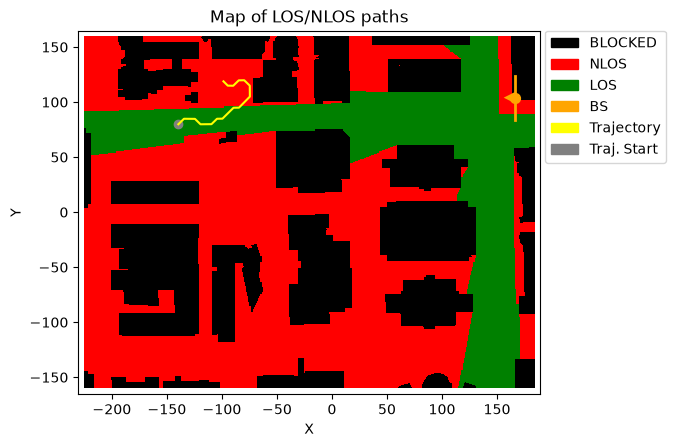

In [3]:
txBearingAngle = 180                                    # Point the TX panel toward the center of the map
bwp = BandwidthPart(numRbs=24, spacing=15)              # Create a BandwidthPart object

# Create a random trajectory
trajectory = dmData.getRandomTrajectory(xyBounds=np.array([[-210, 40], [-70, 120]]),   # Trajectory bounds
                                        segLen=5,       # Number of DeepMIMO grid points on the shortest segment
                                        bwp=bwp,        # The bandwidth part
                                        trajLen=100,    # Number of DeepMIMO grid points on the trajectory
                                        speedMps=15,    # Speed in m/s   
                                        seed=184)       # Make results reproducible   

trajectory.print()                                      # Print the trajectory information
ax = dmData.drawMap("LOS-NLOS", trajectory)             # Draw the map with the trajectory
dmData.drawBsPanel(ax, txBearingAngle)                  # Draw the base station antenna panel

In [4]:
random.setSeed(123)                 # Make results reproducible

# Note:
# Since our goal is to show that different UE locations along a DeepMIMO trajectory experience different 
# BER, we should not normalize the channel gain independently at each location. Per-location
# gain normalization would remove exactly the large-scale variation we want to observe. So, we set 
# the 'normalizeGains' to 'False' in our channel model below and use a fixed noise power.

# Calculate the noise power
k = 1.380649e-23        # Boltzmann constant (joules per kelvin)
tempK = 290.0           # Temperature in kelvin
nf = 8                  # Receiver noise figure (dB)
noiseVarFreq = k*tempK*bwp.spacing*1000*toLinear(nf)

# Creating a trajectory-based channel model
channel = TrjChannel(bwp, trajectory, 
                     normalizeGains = False,
                     txAntenna = AntennaPanel([2,4]),       # 8 TX antennas
                     txOrientation = [txBearingAngle,0,0],  # BS antenna orientation
                     rxAntenna = AntennaPanel([1,2]))       # 2 RX antennas
# channel.print()                   # Uncomment to print the channel model info

pdsch = PDSCH(bwp, numLayers=2, modulation="256QAM")        # PDSCH with one layer
pdsch.setDMRS(configType=1, additionalPos=1)                # DMRS configuration

numSlots = trajectory.numPoints     # Total number of slots = number of points on the trajectory
berInfo = np.zeros((numSlots, 2),dtype=np.int32)
for slotNo in range(numSlots):
    channelMatrix = channel.getChannelMatrix()                  # Get the channel matrix
    precoder = pdsch.getPrecodingMatrix(channelMatrix)          # Get the precoder matrix

    pdsch.initGrid()                                            # Create and initialize PDSCH's internal grid
    numBits = pdsch.getBitCapacity()[0]                         # Number of bits available in the resource grid
    txBits = random.bits(numBits)                               # Create random binary data
            
    # Populate the resource grid with data, including QAM modulation and resource mapping
    pdsch.setPdschData(txBits)
            
    txGrid = bwp.createGrid(len(channel.txAntenna))             # Create the transmitted resource grid
    pdsch.precodeTo(txGrid, precoder)                           # Perform the precoding

    rxGrid = txGrid.applyChannel(channelMatrix)                 # Apply the channel in the frequency domain
    noisyRxGrid = rxGrid.addNoise(noiseVar=noiseVarFreq)        # Add noise

    estChannelMatrix, errVar = pdsch.estimateChannel(rxGrid)            # Channel estimation
    eqGrid, _ = pdsch.equalize(noisyRxGrid, estChannelMatrix, errVar)   # Equalization
    rxBits = pdsch.getHardBits(eqGrid)[0]                       # Demodulation (hard decision)
    berInfo[slotNo, 0] = np.abs(rxBits-txBits).sum()            # Calculate and store the number of bit errors
    berInfo[slotNo, 1] = numBits                                # Store number of bits

    channel.goNext()
    print(f"Slot: {slotNo+1:<6d}  "
          f"BER (%): {berInfo[:,0].sum()*100/berInfo[:,1].sum():<6.2f}  ", end="\r")
    

Slot: 7957    BER (%): 16.50   

In [5]:
# Callback used to initialize and update the scenario map and the graphs below it
def handleGraph(request, ax, trajectory, points=None):
    if request=="Config":
        # BER plot
        ax[0].set_xlim(0,trajectory.numPoints)
        ax[0].set_ylim(0,50)
        ax[0].set_title("BER (%)")
        ax[0].set_xlabel("Trajectory points")
        ax[0].grid()
        ax[0].plot([0], [berInfo[0,0]*100/berInfo[0,1]], 'Red', markersize=1)

    elif request=="ConfigMap":
        ax.set_title("BER along a UE Trajectory")
        ax.drawBsPanel(txBearingAngle)   # Draw TX antenna panel

    elif request=="Draw":
        p0, p1 = points
        sums = berInfo[p0:p1].sum(0)
        ber = sums[0]*100/sums[1]
        return (ax[0].addNewPoint(p1, ber),)
        
# Create the animation and display it below
anim = dmData.animateTrajectory(trajectory, numGraphs=1, pointsPerFrame=100, 
                                graphCallback=handleGraph, fileName='AnimateBER.gif')
display(Markdown("![demo](AnimateBER.gif)"))

# Another option is to use the following command which gives you additional
# control buttons for running the animation.
#    # Increase the animation memory limit for HTML-based animation display
#    matplotlib.rcParams['animation.embed_limit'] = 100000000
#    HTML(anim.to_jshtml())

![demo](AnimateBER.gif)